# RTU 7 - Open-FDD Standalone Notebook

This notebook uses a **shared helper module** so the workflow stays identical across datasets. Only the config block below changes.

> Tested on Windows with pip install of open fdd from PyPi

Assumptions:
- `AHU7.csv` is in the same directory as this notebook
- `openfdd_notebook_helpers.py` is in the same directory as this notebook
- reusable YAML rule files live in `rules/` beside the notebook

In [1]:
#pip install open-fdd pandas matplotlib

In [2]:
from pathlib import Path

# =========================
# USER CONFIGURATION
# =========================

BASE_DIR = Path.cwd()
CSV_FILENAME = "AHU7.csv"
RULES_DIRNAME = "rules"

TIMESTAMP_SOURCE_COL = "timestamp"
TIMESTAMP_COL = "timestamp"
TIMEZONE_SUFFIX_REGEX = None
TIMESTAMP_FORMAT = "%Y-%m-%d %H:%M:%S"

COLUMN_MAP = {'Supply_Air_Temperature_Sensor': 'SAT (°F)', 'Mixed_Air_Temperature_Sensor': 'MAT (°F)', 'Outside_Air_Temperature_Sensor': 'OAT (°F)', 'Return_Air_Temperature_Sensor': 'RAT (°F)', 'Supply_Air_Static_Pressure_Sensor': 'SA Static Press (inH₂O)'}

TEMP_SENSOR_COLS = ['OAT (°F)', 'RAT (°F)', 'MAT (°F)', 'SAT (°F)']
PRESSURE_SENSOR_COLS = ['SA Static Press (inH₂O)']
DIRECT_BOUNDS_MAP = {
    'OAT (°F)': (-20, 120), 
    'RAT (°F)': (50, 90), 
    'MAT (°F)': (35, 95), 
    'SAT (°F)': (45, 95), 
    'SA Static Press (inH₂O)': (-0.05, 3.0)
    }

FAN_STATUS_COL = "SF Sts"
FAN_OUTPUT_COL = "SF Spd Cmd (%)"
FAN_OUTPUT_THRESHOLD = 10.0
REPORT_MOTOR_COL = FAN_STATUS_COL

FAULT_SHADE_FLAG = "bad_sensor_flag"
FLATLINE_FLAG = "flatline_flag"
FAULT_SHADE_ALPHA = 0.18
FIGSIZE_WIDE = (16, 6)
FIGSIZE_MED = (16, 4)

CSV_PATH = BASE_DIR / CSV_FILENAME
RULES_DIR = BASE_DIR / RULES_DIRNAME

print("CSV_PATH =", CSV_PATH)
print("RULES_DIR =", RULES_DIR)
print("TIMESTAMP_SOURCE_COL =", TIMESTAMP_SOURCE_COL)
print("TIMESTAMP_COL =", TIMESTAMP_COL)
print("COLUMN_MAP =", COLUMN_MAP)


CSV_PATH = c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\AHU7.csv
RULES_DIR = c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\rules
TIMESTAMP_SOURCE_COL = timestamp
TIMESTAMP_COL = timestamp
COLUMN_MAP = {'Supply_Air_Temperature_Sensor': 'SAT (°F)', 'Mixed_Air_Temperature_Sensor': 'MAT (°F)', 'Outside_Air_Temperature_Sensor': 'OAT (°F)', 'Return_Air_Temperature_Sensor': 'RAT (°F)', 'Supply_Air_Static_Pressure_Sensor': 'SA Static Press (inH₂O)'}


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from openfdd_notebook_helpers_v2 import (
    load_dataset,
    run_openfdd,
    get_flag_cols,
    summarize_flags,
    add_direct_bounds_flags,
    summarize_bad_sensors,
    shade_flag_windows,
    plot_series_with_fault_shading,
    plot_sensor_with_bad_windows,
    plot_sensor_with_openfdd_overlap,
    compute_fan_runtime,
    weekly_fan_runtime,
    plot_weekly_fan_runtime,
    plot_fault_pies,
    plot_sensor_fault_pies,
    report_outputs,
)

plt.style.use("seaborn-v0_8-whitegrid")


## Load and parse the CSV

In [4]:
df = load_dataset(
    csv_path=CSV_PATH,
    timestamp_source_col=TIMESTAMP_SOURCE_COL,
    timestamp_col=TIMESTAMP_COL,
    timestamp_format=TIMESTAMP_FORMAT,
    timezone_suffix_regex=TIMEZONE_SUFFIX_REGEX,
)

preview_cols = [TIMESTAMP_SOURCE_COL]
if TIMESTAMP_COL != TIMESTAMP_SOURCE_COL:
    preview_cols.append(TIMESTAMP_COL)

print(df[preview_cols].head())
print()
print(df.dtypes)


            timestamp
0 2025-01-01 00:00:00
1 2025-01-01 00:15:00
2 2025-01-01 00:30:00
3 2025-01-01 00:45:00
4 2025-01-01 01:00:00

timestamp                  datetime64[ns]
Clg Vlv Cmd (%)                   float64
OA Damper Cmd (%)                 float64
Prht Vlv Cmd (%)                  float64
RA_EA Damper Cmd (%)              float64
RF Spd Cmd (%)                    float64
SF Spd Cmd (%)                    float64
SA Static Press (inH₂O)           float64
Eff SAT Sp (°F)                   float64
MAT (°F)                          float64
OAT (°F)                          float64
RAT (°F)                          float64
SAT (°F)                          float64
Econ Ena                          float64
EF Ena                            float64
Occupancy                         float64
RF Cmd                            float64
RF Sts                            float64
SF Cmd                            float64
Schedule                          float64
SF Sts                     

## Run Open-FDD YAML rules

In [5]:
df_result = run_openfdd(
    df=df,
    rules_dir=RULES_DIR,
    timestamp_col=TIMESTAMP_COL,
    column_map=COLUMN_MAP,
)

print("Rows, Cols:", df_result.shape)
df_result.head()


Rows, Cols: (10213, 23)


,timestamp,Clg Vlv Cmd (%),OA Damper Cmd (%),Prht Vlv Cmd (%),RA_EA Damper Cmd (%),RF Spd Cmd (%),SF Spd Cmd (%),SA Static Press (inH₂O),Eff SAT Sp (°F),MAT (°F),...,Econ Ena,EF Ena,Occupancy,RF Cmd,RF Sts,SF Cmd,Schedule,SF Sts,bad_sensor_flag,flatline_flag
0,2025-01-01 00:00:00,0.0,0.0,100.0,0.0,0.0,0.0,0.026875,70.0,66.379997,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,2025-01-01 00:15:00,0.0,0.0,100.0,0.0,0.0,0.0,0.026875,70.0,66.038002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2025-01-01 00:30:00,0.0,0.0,100.0,0.0,0.0,0.0,0.026875,70.0,65.786003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2025-01-01 00:45:00,0.0,0.0,100.0,0.0,0.0,0.0,0.026875,70.0,65.695999,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,2025-01-01 01:00:00,0.0,0.0,100.0,0.0,0.0,0.0,0.026875,70.0,65.570000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [6]:
flag_cols = get_flag_cols(df_result)
print("Flag columns:", flag_cols)
df_result[[TIMESTAMP_COL] + flag_cols].head()


Flag columns: ['bad_sensor_flag', 'flatline_flag']


,timestamp,bad_sensor_flag,flatline_flag
0,2025-01-01 00:00:00,0,0
1,2025-01-01 00:15:00,0,0
2,2025-01-01 00:30:00,0,0
3,2025-01-01 00:45:00,0,0
4,2025-01-01 01:00:00,0,0


In [7]:
fault_summary = summarize_flags(df_result, flag_cols)
fault_summary


,fault_count
flatline_flag,5729
bad_sensor_flag,2904


## Direct per-sensor bounds for quick visual debugging

In [8]:
df_result, bounds_fault_cols = add_direct_bounds_flags(df_result, DIRECT_BOUNDS_MAP)
print("Per-sensor bounds fault columns:")
print(bounds_fault_cols)


Per-sensor bounds fault columns:
['OAT (°F)_bounds_fault', 'RAT (°F)_bounds_fault', 'MAT (°F)_bounds_fault', 'SAT (°F)_bounds_fault', 'SA Static Press (inH₂O)_bounds_fault']


In [9]:
bounds_fault_summary = summarize_bad_sensors(df_result, bounds_fault_cols)
bounds_fault_summary


,bad_count
SAT (°F)_bounds_fault,2501
RAT (°F)_bounds_fault,158
MAT (°F)_bounds_fault,42
OAT (°F)_bounds_fault,0
SA Static Press (inH₂O)_bounds_fault,0


## Open-FDD reports helpers

In [10]:
report_motor_col = REPORT_MOTOR_COL if REPORT_MOTOR_COL in df_result.columns else FAN_OUTPUT_COL
report_summary_df, bounds_episodes_df, flatline_episodes_df = report_outputs(
    df_result=df_result,
    flag_cols=flag_cols,
    report_motor_col=report_motor_col,
    column_map=COLUMN_MAP,
    timestamp_col=TIMESTAMP_COL,
    bounds_map=DIRECT_BOUNDS_MAP,
    flatline_flag=FLATLINE_FLAG,
)

report_summary_df


,error
bad_sensor_flag,DataFrame must have DatetimeIndex
flatline_flag,DataFrame must have DatetimeIndex


In [11]:
bounds_episodes_df.head(20)


,start_ts,end_ts,sensors_flat,all_sensors_flat,single_sensor_flat,rows,sensor_means
0,2025-01-02 21:00:00,2025-01-03 06:15:00,[],False,False,38,{}
1,2025-01-04 01:00:00,2025-01-04 01:00:00,[],False,False,1,{}
2,2025-01-04 03:15:00,2025-01-06 05:15:00,[],False,False,200,{}
3,2025-01-06 22:45:00,2025-01-07 01:00:00,[],False,False,10,{}
4,2025-01-07 02:15:00,2025-01-07 03:00:00,[],False,False,4,{}
5,2025-01-07 06:00:00,2025-01-07 06:15:00,[],False,False,2,{}
6,2025-01-08 00:30:00,2025-01-08 06:15:00,[],False,False,24,{}
7,2025-01-08 18:45:00,2025-01-09 06:15:00,[],False,False,47,{}
8,2025-01-09 18:45:00,2025-01-10 06:15:00,[],False,False,47,{}
9,2025-01-10 18:45:00,2025-01-13 05:15:00,[],False,False,234,{}


In [12]:
flatline_episodes_df.head(20)


,start_ts,end_ts,sensors_flat,all_sensors_flat,single_sensor_flat,rows,sensor_last_values
0,2025-01-01 04:15:00,2025-01-01 06:15:00,"[Supply_Air_Temperature_Sensor, Mixed_Air_Temp...",True,False,9,"{'Supply_Air_Temperature_Sensor': [60.8, 60.8,..."
1,2025-01-01 22:15:00,2025-01-02 01:45:00,[Supply_Air_Static_Pressure_Sensor],False,True,15,"{'Supply_Air_Static_Pressure_Sensor': [0.03, 0..."
2,2025-01-02 23:15:00,2025-01-03 01:15:00,[Supply_Air_Static_Pressure_Sensor],False,True,9,"{'Supply_Air_Static_Pressure_Sensor': [0.03, 0..."
3,2025-01-05 06:00:00,2025-01-05 08:45:00,[Outside_Air_Temperature_Sensor],False,True,12,"{'Outside_Air_Temperature_Sensor': [21.0, 21.0..."
4,2025-01-06 02:15:00,2025-01-06 05:15:00,[Supply_Air_Static_Pressure_Sensor],False,True,13,"{'Supply_Air_Static_Pressure_Sensor': [0.03, 0..."
5,2025-01-07 00:45:00,2025-01-07 06:15:00,[Supply_Air_Static_Pressure_Sensor],False,True,23,"{'Supply_Air_Static_Pressure_Sensor': [0.03, 0..."
6,2025-01-07 23:45:00,2025-01-08 06:00:00,[Supply_Air_Static_Pressure_Sensor],False,True,25,"{'Supply_Air_Static_Pressure_Sensor': [0.03, 0..."
7,2025-01-08 22:15:00,2025-01-09 06:15:00,[Supply_Air_Static_Pressure_Sensor],False,True,33,"{'Supply_Air_Static_Pressure_Sensor': [0.03, 0..."
8,2025-01-09 11:45:00,2025-01-09 18:00:00,[Outside_Air_Temperature_Sensor],False,True,24,"{'Outside_Air_Temperature_Sensor': [70.0, 70.0..."
9,2025-01-09 22:15:00,2025-01-10 06:15:00,"[Outside_Air_Temperature_Sensor, Supply_Air_St...",False,False,33,"{'Outside_Air_Temperature_Sensor': [70.0, 70.0..."


## Shaded fault-window plots

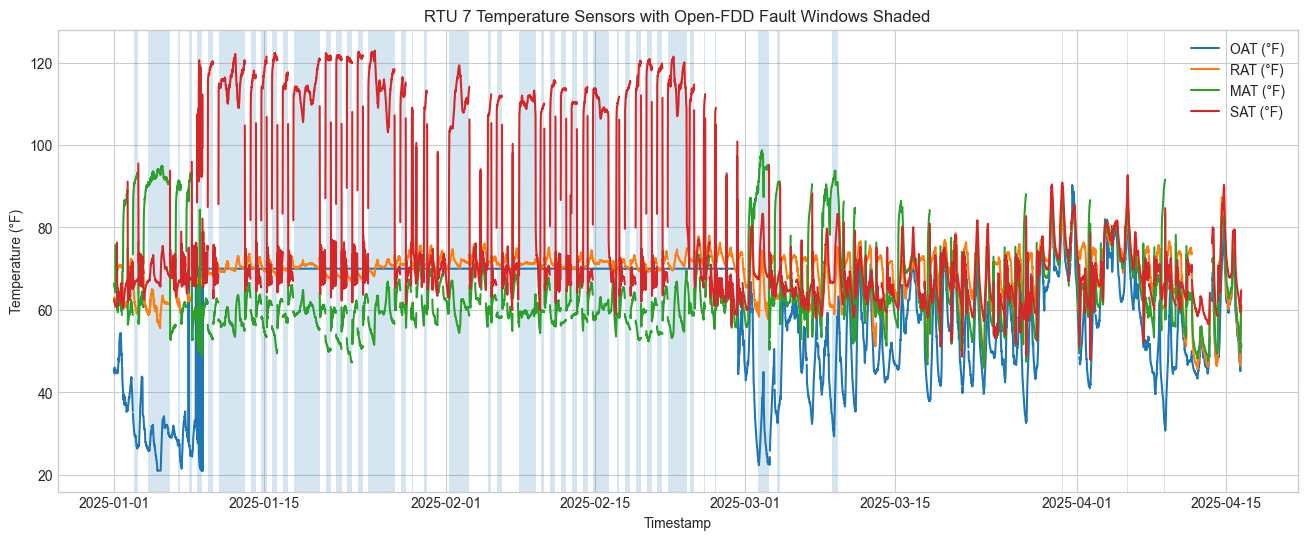

In [13]:
plot_series_with_fault_shading(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    series_cols=TEMP_SENSOR_COLS,
    fault_flag_col=FAULT_SHADE_FLAG,
    title="RTU 7 Temperature Sensors with Open-FDD Fault Windows Shaded",
    ylabel="Temperature (°F)",
    figsize=FIGSIZE_WIDE,
    shade_alpha=FAULT_SHADE_ALPHA,
)


c:\Users\ben\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


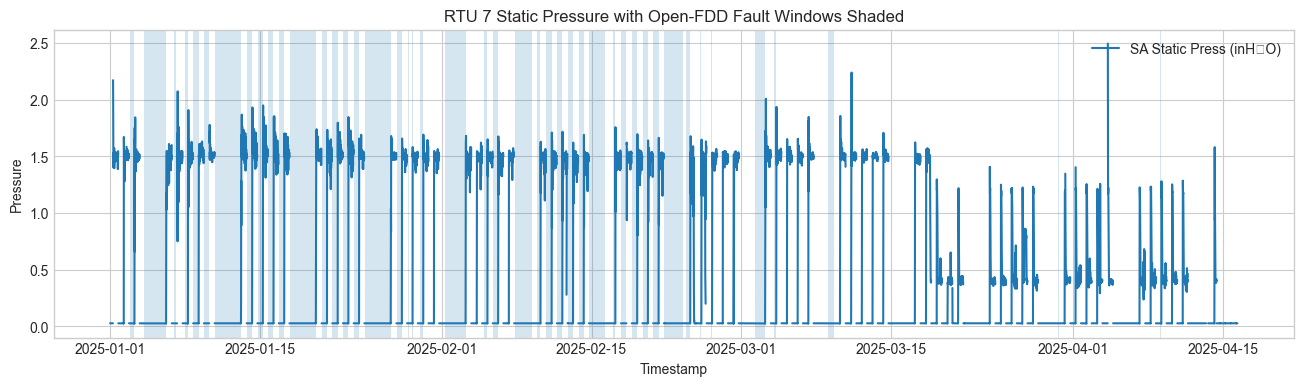

In [14]:
plot_series_with_fault_shading(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    series_cols=PRESSURE_SENSOR_COLS,
    fault_flag_col=FAULT_SHADE_FLAG,
    title="RTU 7 Static Pressure with Open-FDD Fault Windows Shaded",
    ylabel="Pressure",
    figsize=FIGSIZE_MED,
    shade_alpha=FAULT_SHADE_ALPHA,
)


## Zoom in on individual sensors

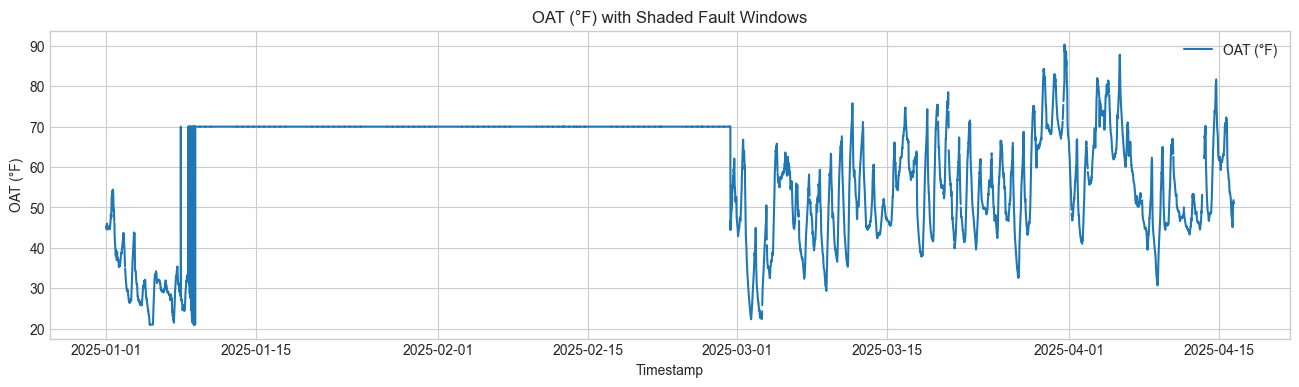

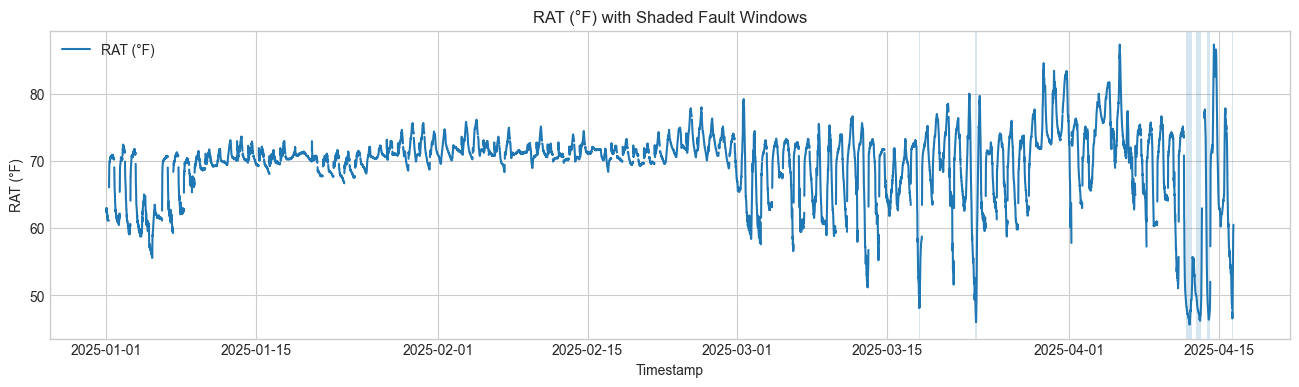

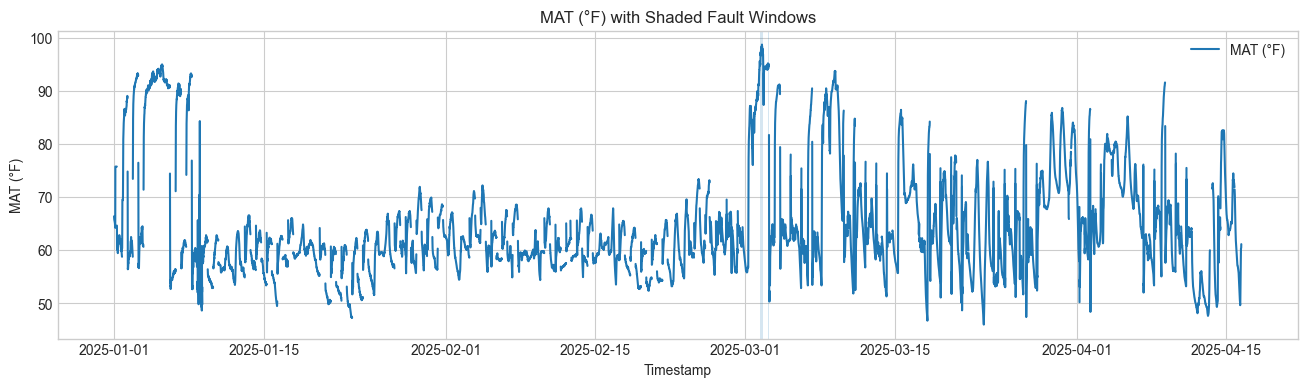

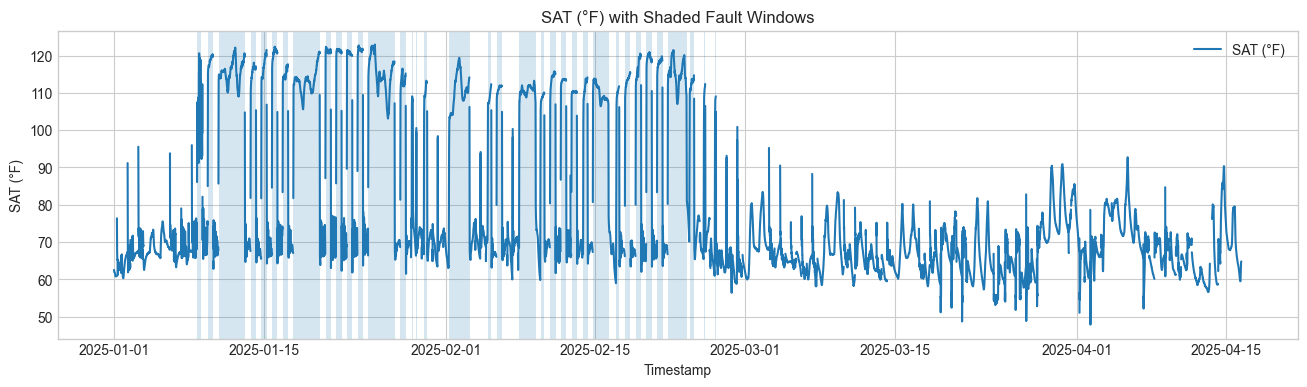

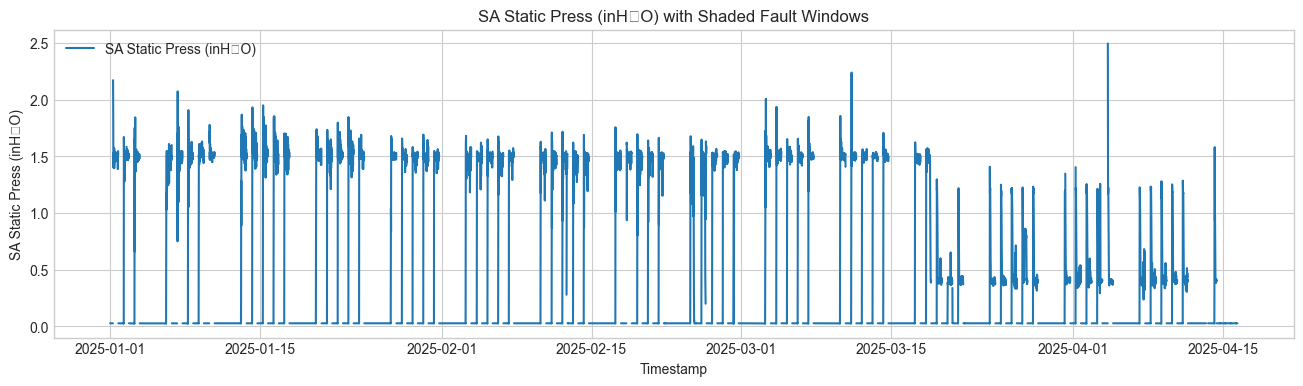

In [15]:
for sensor in DIRECT_BOUNDS_MAP.keys():
    plot_sensor_with_bad_windows(
        df_result=df_result,
        timestamp_col=TIMESTAMP_COL,
        sensor_col=sensor,
        fault_suffix="_bounds_fault",
        figsize=FIGSIZE_MED,
        shade_alpha=FAULT_SHADE_ALPHA,
    )


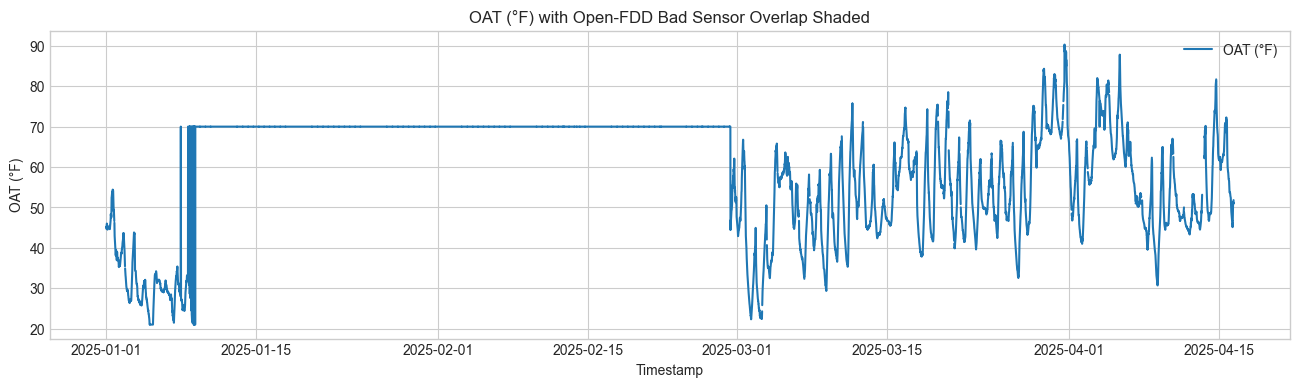

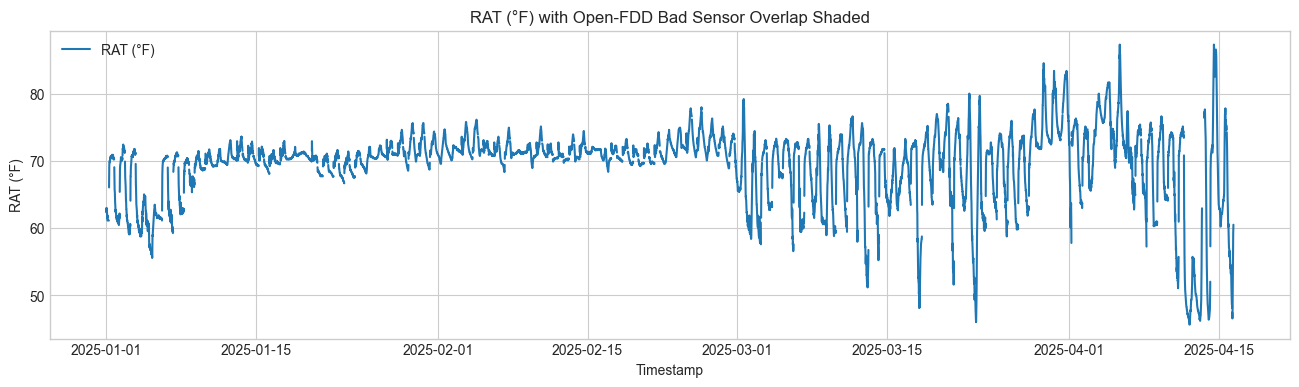

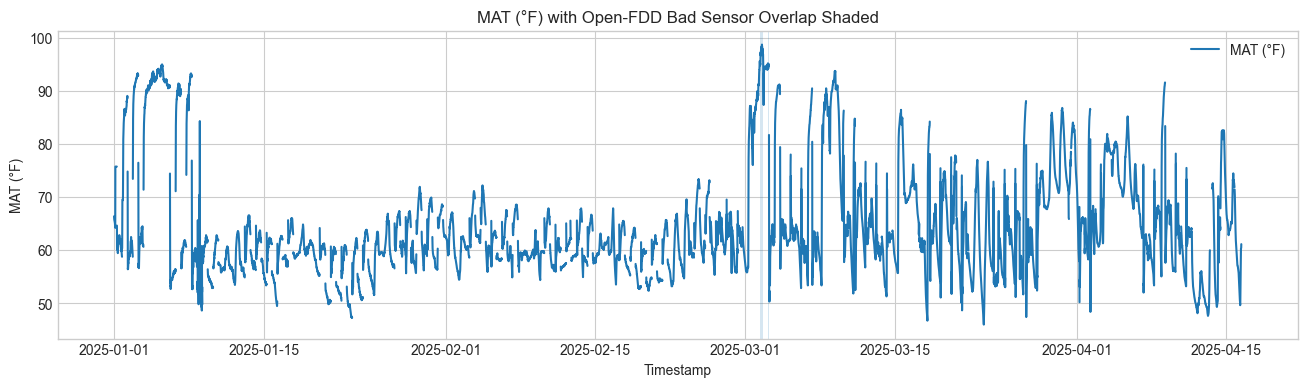

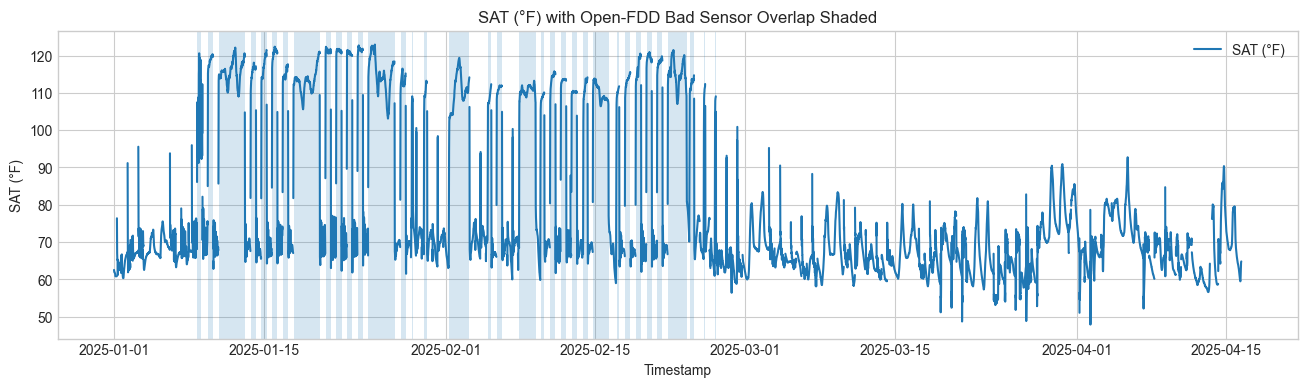

c:\Users\ben\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


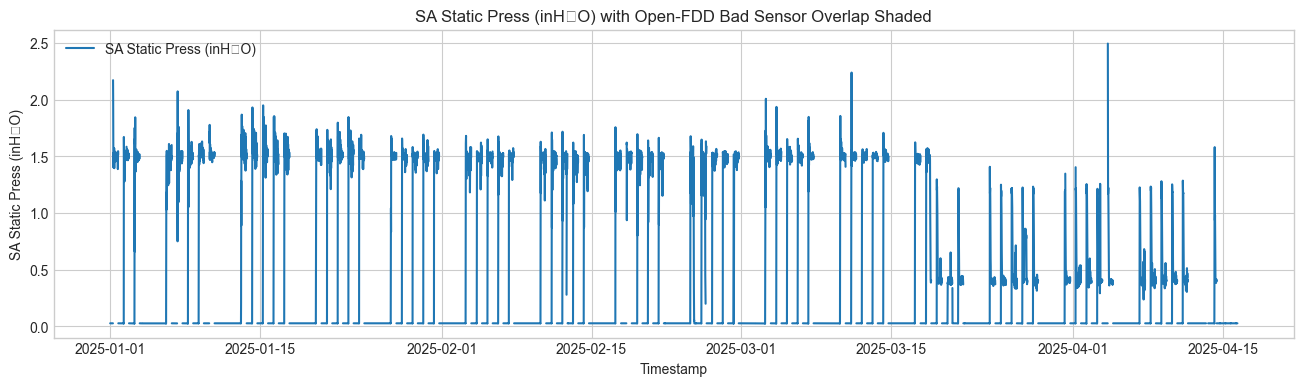

In [16]:
for sensor in DIRECT_BOUNDS_MAP.keys():
    plot_sensor_with_openfdd_overlap(
        df_result=df_result,
        timestamp_col=TIMESTAMP_COL,
        sensor_col=sensor,
        fault_flag_col=FAULT_SHADE_FLAG,
        fault_suffix="_bounds_fault",
        figsize=FIGSIZE_MED,
        shade_alpha=FAULT_SHADE_ALPHA,
    )


In [17]:
direct_bad_mask = df_result[[f"{c}_bounds_fault" for c in DIRECT_BOUNDS_MAP.keys()]].any(axis=1)

df_result.loc[
    direct_bad_mask,
    [TIMESTAMP_COL] + list(DIRECT_BOUNDS_MAP.keys()) + [f"{c}_bounds_fault" for c in DIRECT_BOUNDS_MAP.keys()]
].head(50)


,timestamp,OAT (°F),RAT (°F),MAT (°F),SAT (°F),SA Static Press (inH₂O),OAT (°F)_bounds_fault,RAT (°F)_bounds_fault,MAT (°F)_bounds_fault,SAT (°F)_bounds_fault,SA Static Press (inH₂O)_bounds_fault
220,2025-01-03 06:30:00,27.145500,64.094002,76.477997,95.540001,0.024375,0,0,0,1,0
431,2025-01-05 11:30:00,29.892099,62.438000,95.017998,73.975998,0.026250,0,0,1,0,0
432,2025-01-05 11:45:00,30.563400,62.653999,95.017998,74.138000,0.026250,0,0,1,0,0
700,2025-01-08 06:30:00,25.636900,65.281998,76.891998,95.954002,0.025000,0,0,0,1,0
749,2025-01-08 18:30:00,70.000000,68.234001,53.528000,103.099998,0.026875,0,0,0,1,0
750,2025-01-08 18:45:00,70.000000,68.143997,53.203999,97.033997,0.026875,0,0,0,1,0
751,2025-01-08 19:00:00,70.000000,68.071999,52.736000,107.510002,0.026875,0,0,0,1,0
752,2025-01-08 19:15:00,28.610800,68.108002,53.077999,99.571999,0.026875,0,0,0,1,0
755,2025-01-08 20:00:00,27.621599,66.758003,65.660004,98.636002,0.026875,0,0,0,1,0
756,2025-01-08 20:15:00,70.000000,67.676003,53.528000,97.753998,0.026875,0,0,0,1,0


## Fan runtime KPIs

In [18]:
df_result, fan_logic_used, total_fan_run_hours = compute_fan_runtime(
    df_result=df_result,
    timestamp_col=TIMESTAMP_COL,
    fan_status_col=FAN_STATUS_COL,
    fan_output_col=FAN_OUTPUT_COL,
    fan_output_threshold=FAN_OUTPUT_THRESHOLD,
)

print("Fan logic used:", fan_logic_used)
print(f"Total fan run hours: {total_fan_run_hours:.2f}")


Fan logic used: SF Sts parsed as numeric/text status, forward-filled
Total fan run hours: 332.15


c:\Users\ben\OneDrive\Desktop\BensOpenClawTesting\examples\AHU\openfdd_notebook_helpers_v2.py:213: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_result["fan_on"] = status_bool.ffill().fillna(False).astype(bool)


In [19]:
weekly_fan_hours = weekly_fan_runtime(df_result, TIMESTAMP_COL)
weekly_fan_hours.head()


timestamp
2025-01-05    17.566667
2025-01-12     0.000000
2025-01-19    17.566667
2025-01-26    18.566667
2025-02-02     0.000000
Freq: W-SUN, Name: fan_run_hours, dtype: float64

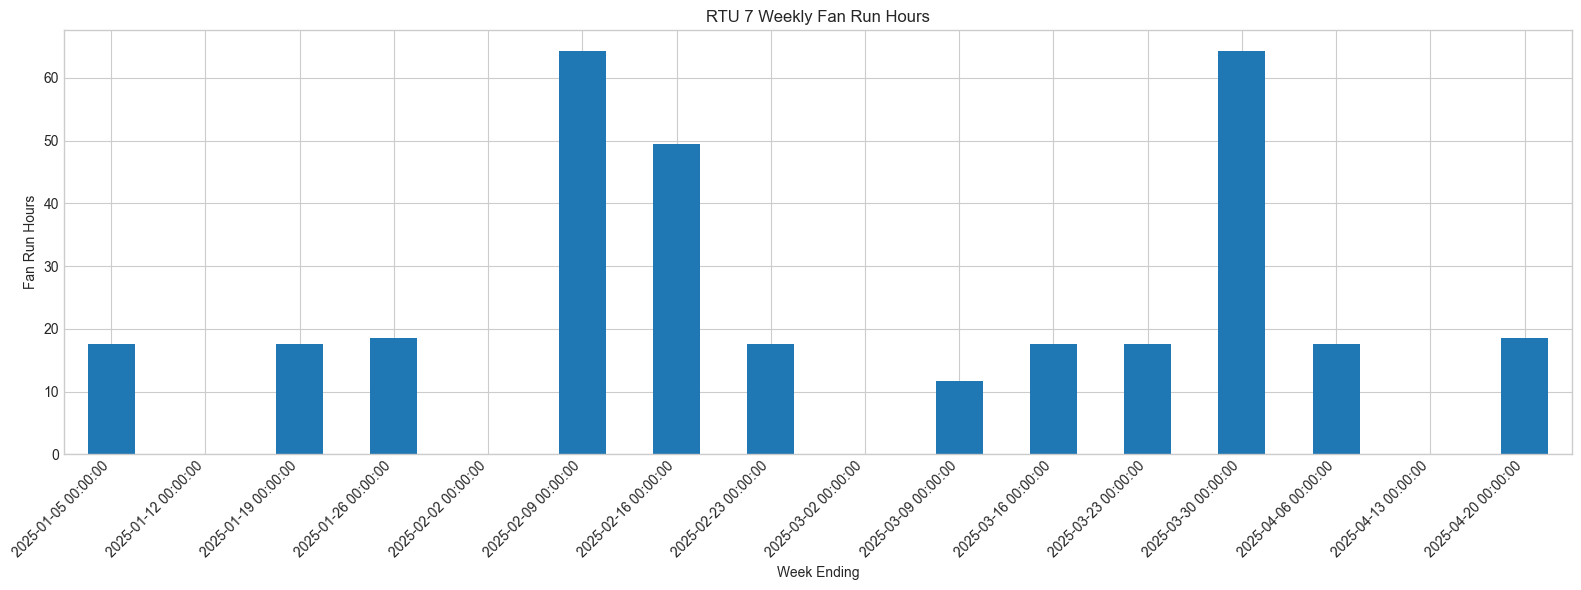

In [20]:
plot_weekly_fan_runtime(
    weekly_fan_hours,
    title="RTU 7 Weekly Fan Run Hours",
    figsize=FIGSIZE_WIDE,
)


for sensor in DIRECT_BOUNDS_MAP.keys():
    plot_sensor_fault_pies(
        df_result=df_result,
        sensor_col=sensor,
        rule_name="Bounds",
        fault_suffix="_bounds_fault",
        bounds_map=DIRECT_BOUNDS_MAP,
    )


## Aggregate pie charts from Open-FDD flags

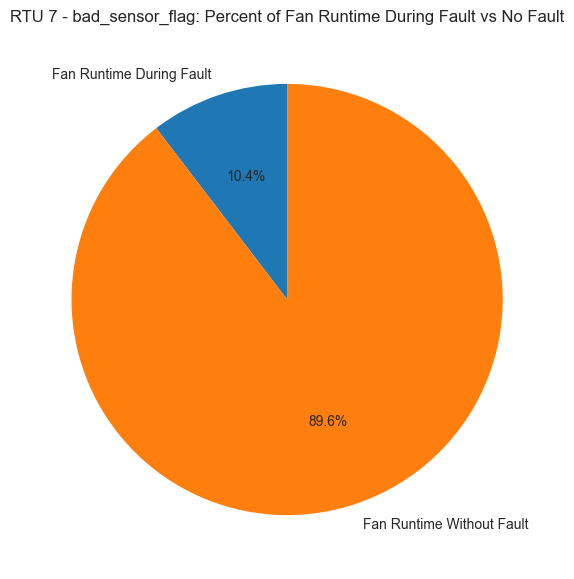

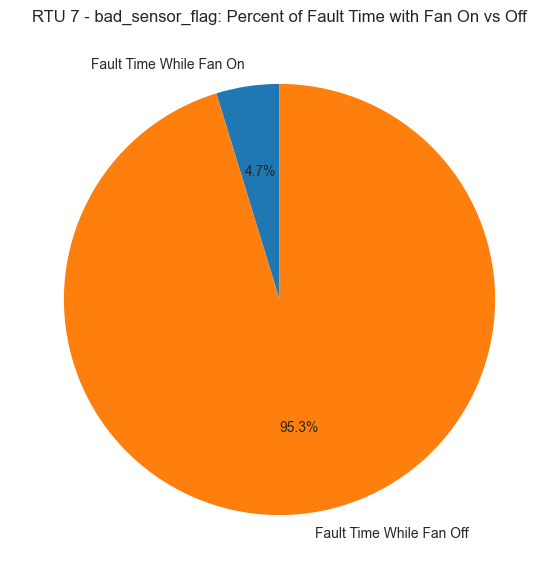

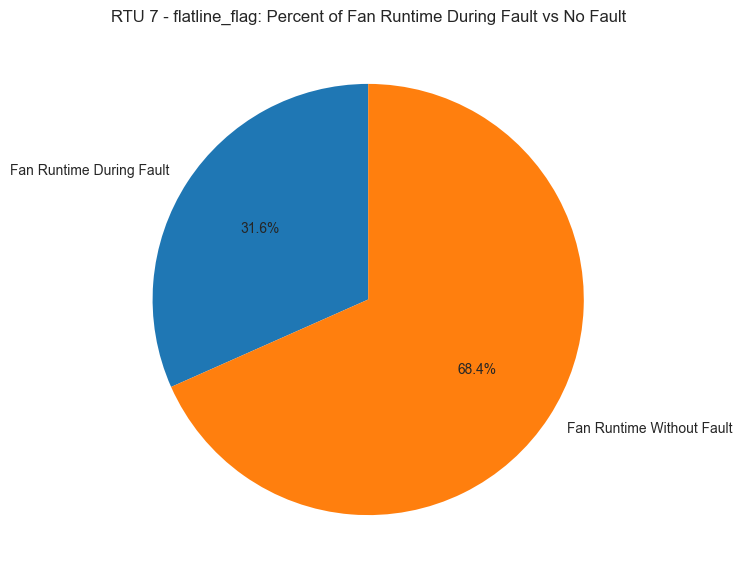

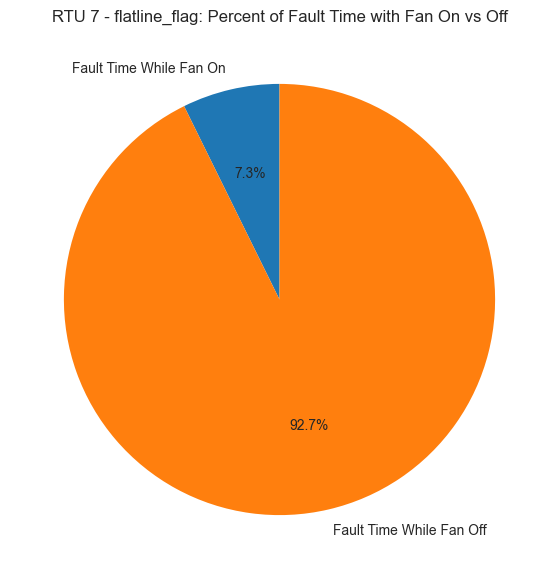

In [21]:
plot_fault_pies(df_result, FAULT_SHADE_FLAG, title_prefix="RTU 7 - bad_sensor_flag")
plot_fault_pies(df_result, FLATLINE_FLAG, title_prefix="RTU 7 - flatline_flag")
